=== MAPPING ACCURACY SUMMARY ===
GO ID to Term: 18.38% (338/1839)
GO Term to ID: 35.62% (655/1839)
HPO ID to Term: 0.16% (31/18800)
HPO Term to ID: 8.8% (1654/18800)
Protein to Gene Name: 95.25% (3792/3981)
Gene to Protein Name: 59.67% (2375/3980)


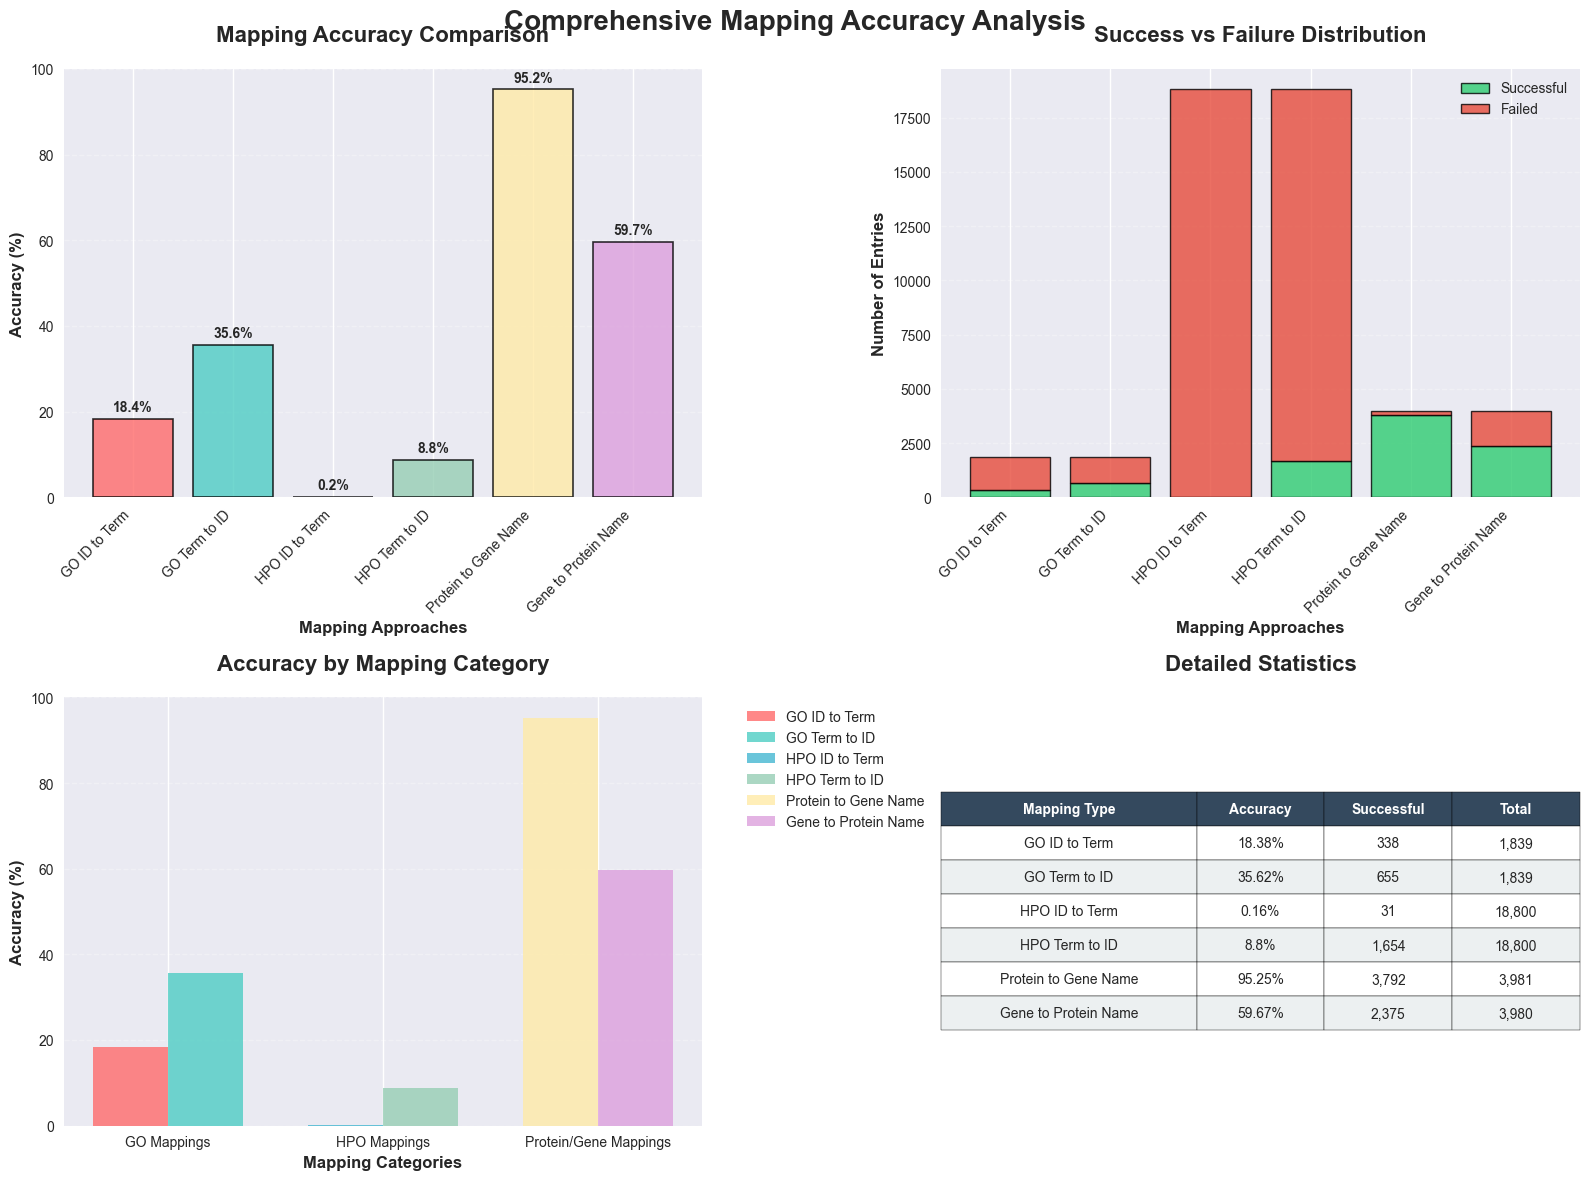


=== KEY INSIGHTS ===
1. Best performing mapping: Protein to Gene Name (95.25%)
2. Worst performing mapping: HPO ID to Term (0.16%)
3. Average accuracy across all mappings: 36.31%
4. Total entries processed: 49,239
5. Total successful mappings: 8,845


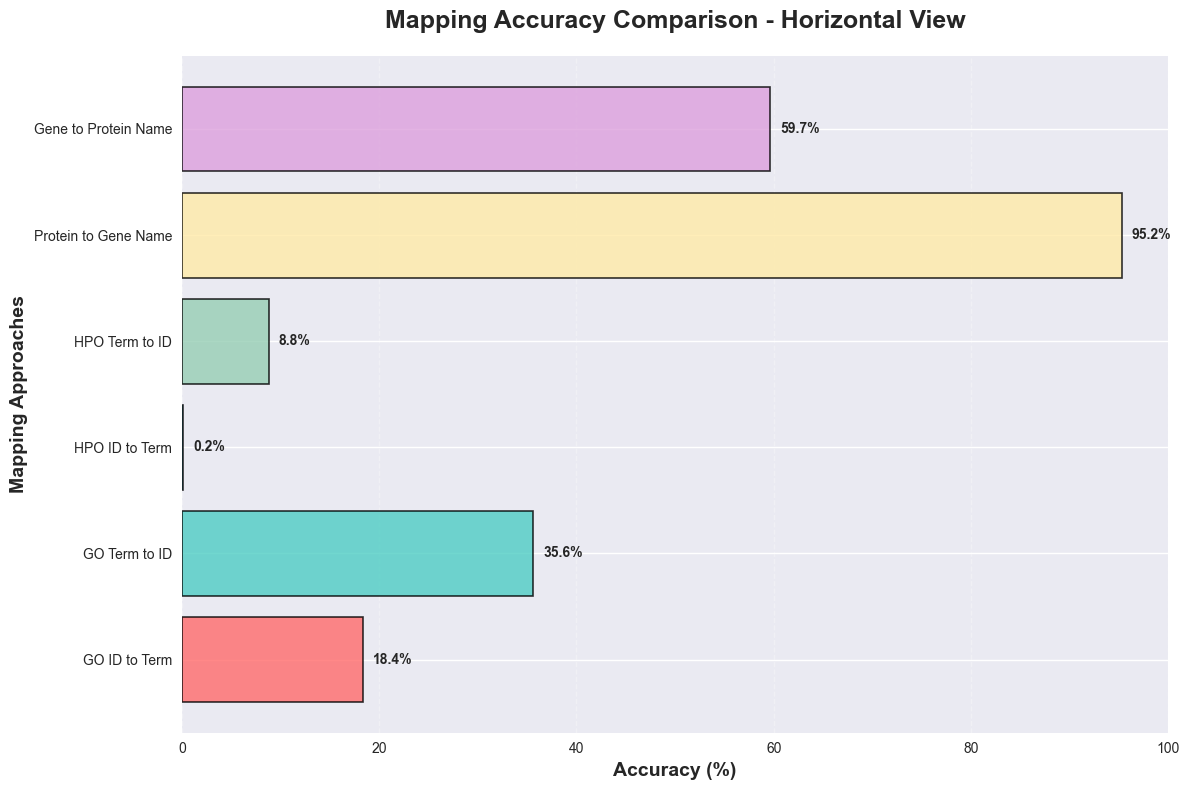


Results saved to 'mapping_accuracy_summary.csv'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def calculate_accuracy(csv_file, mapping_type):
    """Calculate accuracy from mapping results CSV file"""
    df = pd.read_csv(csv_file)
    matches = df[df['match'] == 1].shape[0]
    total = df.shape[0]
    accuracy = (matches / total) * 100
    return {
        'Mapping Type': mapping_type,
        'Accuracy (%)': round(accuracy, 2),
        'Successful Matches': matches,
        'Total Entries': total,
        'Failed Matches': total - matches
    }

# Calculate accuracies for all mapping approaches
mapping_results = []

# GO mappings
mapping_results.append(calculate_accuracy('Gpt Id to terms/go_term_mapping_results.csv', 'GO ID to Term'))
mapping_results.append(calculate_accuracy('Gpt term to id/go_id_mapping_results.csv', 'GO Term to ID'))

# HPO mappings
mapping_results.append(calculate_accuracy('Gpt Id to terms/hpo_term_mapping_results.csv', 'HPO ID to Term'))
mapping_results.append(calculate_accuracy('Gpt term to id/hpo_id_mapping_results.csv', 'HPO Term to ID'))

# Protein/Gene mappings
mapping_results.append(calculate_accuracy('Gpt term to id/protein_gn_mapping_results.csv', 'Protein to Gene Name'))
mapping_results.append(calculate_accuracy('Gpt Id to terms/gene_protein_mapping_results.csv', 'Gene to Protein Name'))

# Convert to DataFrame
df_results = pd.DataFrame(mapping_results)

# Print results summary
print("=== MAPPING ACCURACY SUMMARY ===")
for _, row in df_results.iterrows():
    print(f"{row['Mapping Type']}: {row['Accuracy (%)']}% ({row['Successful Matches']}/{row['Total Entries']})")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive Mapping Accuracy Analysis', fontsize=20, fontweight='bold', y=0.98)

# 1. Main Bar Chart - Accuracy Comparison
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = ax1.bar(range(len(df_results)), df_results['Accuracy (%)'], 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax1.set_title('Mapping Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mapping Approaches', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(df_results)))
ax1.set_xticklabels(df_results['Mapping Type'], rotation=45, ha='right')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Success vs Failure Stacked Bar Chart
successful = df_results['Successful Matches']
failed = df_results['Failed Matches']

ax2.bar(range(len(df_results)), successful, color='#2ECC71', alpha=0.8, 
        label='Successful', edgecolor='black', linewidth=1)
ax2.bar(range(len(df_results)), failed, bottom=successful, color='#E74C3C', 
        alpha=0.8, label='Failed', edgecolor='black', linewidth=1)

ax2.set_title('Success vs Failure Distribution', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Number of Entries', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mapping Approaches', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(df_results)))
ax2.set_xticklabels(df_results['Mapping Type'], rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Grouped Bar Chart by Category
go_data = df_results[df_results['Mapping Type'].str.contains('GO')]
hpo_data = df_results[df_results['Mapping Type'].str.contains('HPO')]
protein_data = df_results[df_results['Mapping Type'].str.contains('Protein|Gene')]

categories = ['GO Mappings', 'HPO Mappings', 'Protein/Gene Mappings']
category_data = [go_data, hpo_data, protein_data]

x = np.arange(len(categories))
width = 0.35

for i, cat_data in enumerate(category_data):
    if len(cat_data) == 2:
        ax3.bar(x[i] - width/2, cat_data.iloc[0]['Accuracy (%)'], width, 
                color=colors[i*2], alpha=0.8, label=cat_data.iloc[0]['Mapping Type'])
        ax3.bar(x[i] + width/2, cat_data.iloc[1]['Accuracy (%)'], width, 
                color=colors[i*2+1], alpha=0.8, label=cat_data.iloc[1]['Mapping Type'])

ax3.set_title('Accuracy by Mapping Category', fontsize=16, fontweight='bold', pad=20)
ax3.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mapping Categories', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 4. Summary Statistics Table
ax4.axis('tight')
ax4.axis('off')
ax4.set_title('Detailed Statistics', fontsize=16, fontweight='bold', pad=20)

# Prepare table data
table_data = []
for _, row in df_results.iterrows():
    table_data.append([
        row['Mapping Type'],
        f"{row['Accuracy (%)']}%",
        f"{row['Successful Matches']:,}",
        f"{row['Total Entries']:,}"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['Mapping Type', 'Accuracy', 'Successful', 'Total'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.4, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the table
for i in range(len(table_data) + 1):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0:  # Header row
            cell.set_facecolor('#34495E')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#ECF0F1' if i % 2 == 0 else 'white')
            cell.set_text_props(weight='normal')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Print key insights
print("\n=== KEY INSIGHTS ===")
print(f"1. Best performing mapping: {df_results.loc[df_results['Accuracy (%)'].idxmax(), 'Mapping Type']} ({df_results['Accuracy (%)'].max():.2f}%)")
print(f"2. Worst performing mapping: {df_results.loc[df_results['Accuracy (%)'].idxmin(), 'Mapping Type']} ({df_results['Accuracy (%)'].min():.2f}%)")
print(f"3. Average accuracy across all mappings: {df_results['Accuracy (%)'].mean():.2f}%")
print(f"4. Total entries processed: {df_results['Total Entries'].sum():,}")
print(f"5. Total successful mappings: {df_results['Successful Matches'].sum():,}")

# Create a simple horizontal bar chart for better readability
plt.figure(figsize=(12, 8))
plt.barh(range(len(df_results)), df_results['Accuracy (%)'], 
         color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

plt.title('Mapping Accuracy Comparison - Horizontal View', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.ylabel('Mapping Approaches', fontsize=14, fontweight='bold')
plt.yticks(range(len(df_results)), df_results['Mapping Type'])
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(df_results['Accuracy (%)']):
    plt.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Save results to CSV for further analysis
df_results.to_csv('mapping_accuracy_summary.csv', index=False)
print(f"\nResults saved to 'mapping_accuracy_summary.csv'")

Loading bidirectional mapping data...
Calculating accuracy metrics...
Creating clean bidirectional chart...


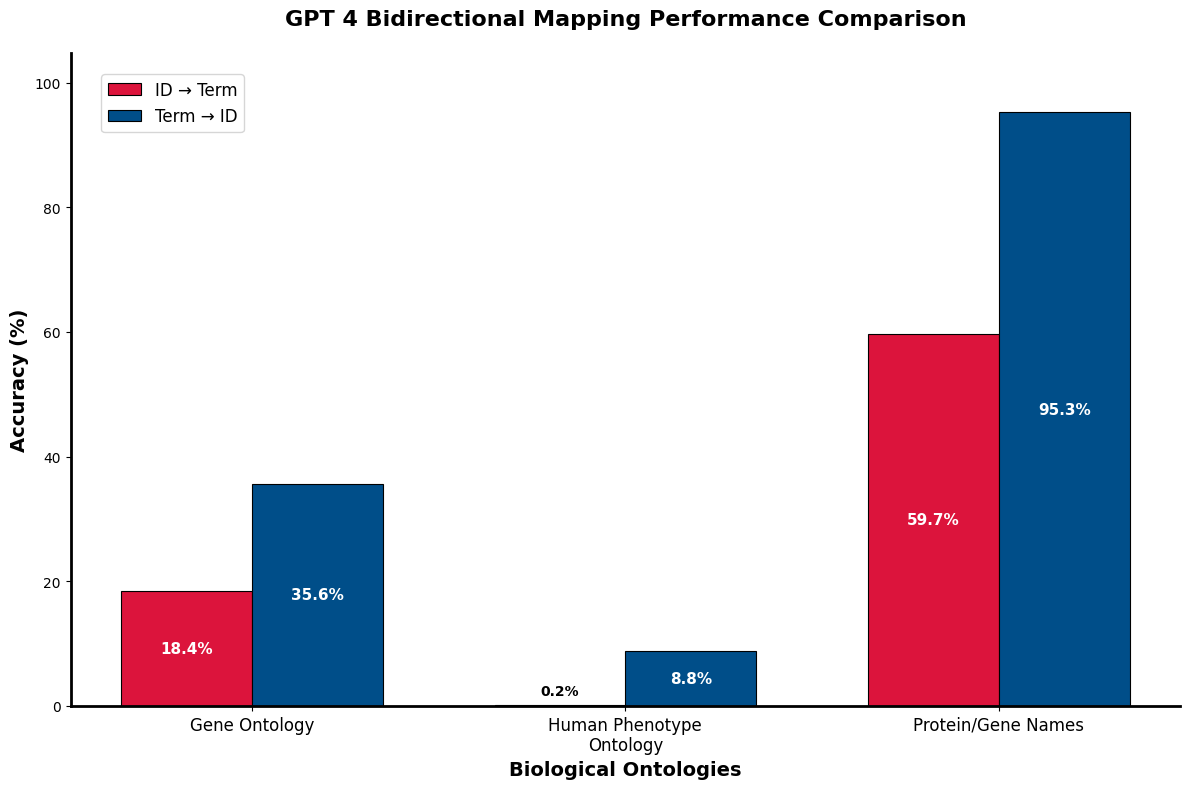


Results:
GO: ID→Term 18.4%, Term→ID 35.6%
HPO: ID→Term 0.2%, Term→ID 8.8%
Protein: ID→Term 59.7%, Term→ID 95.3%


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_mapping_data():
    """Load all bidirectional mapping results"""
    
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Gpt Id to terms/go_term_mapping_results.csv')
    hpo_term_results = pd.read_csv('Gpt Id to terms/hpo_term_mapping_results.csv')
    protein_name_results = pd.read_csv('Gpt Id to terms/gene_protein_mapping_results.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Gpt term to id/go_id_mapping_results.csv')
    hpo_id_results = pd.read_csv('Gpt term to id/hpo_id_mapping_results.csv')
    protein_gn_results = pd.read_csv('Gpt term to id/protein_gn_mapping_results.csv')
    
    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def calculate_accuracy_metrics(data):
    """Calculate accuracy metrics for all mapping directions"""
    
    results = {}
    
    # ID → Term accuracies
    results['GO ID→Term'] = (data['go_id_to_term']['match'] == 1).mean() * 100
    results['HPO ID→Term'] = (data['hpo_id_to_term']['match'] == 1).mean() * 100
    results['Protein ID→Name'] = (data['protein_id_to_name']['match'] == 1).mean() * 100
    
    # Term → ID accuracies
    results['GO Term→ID'] = (data['go_term_to_id']['match'] == 1).mean() * 100
    results['HPO Term→ID'] = (data['hpo_term_to_id']['match'] == 1).mean() * 100
    results['Protein Name→GN'] = (data['protein_name_to_gn']['match'] == 1).mean() * 100
    
    return results

def create_clean_bidirectional_chart(accuracy_results):
    """Create a clean bidirectional comparison chart with bright colors and borders"""
    
    # Set clean white background
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data for plotting
    ontologies = ['Gene Ontology', 'Human Phenotype\nOntology', 'Protein/Gene Names']
    id_to_term = [accuracy_results['GO ID→Term'], 
                  accuracy_results['HPO ID→Term'], 
                  accuracy_results['Protein ID→Name']]
    term_to_id = [accuracy_results['GO Term→ID'], 
                  accuracy_results['HPO Term→ID'], 
                  accuracy_results['Protein Name→GN']]
    
    x = np.arange(len(ontologies))
    width = 0.35
    
    # Bright colors with borders
    color1 = '#DC143C'  # Bright red
    color2 = '#004E89'  # Deep blue
    
    # Create bars with black borders
    bars1 = ax.bar(x - width/2, id_to_term, width, 
                   label='ID → Term', 
                   color=color1, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    bars2 = ax.bar(x + width/2, term_to_id, width, 
                   label='Term → ID', 
                   color=color2, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    # Customize plot - remove all grid lines and background elements
    ax.set_xlabel('Biological Ontologies', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('GPT 4 Bidirectional Mapping Performance Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(ontologies, fontsize=12)
    ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(0.02, 0.98))
    
    # Remove all grid lines and spines except bottom and left
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Set y-axis to start from 0 with better range for small values
    max_val = max(max(id_to_term), max(term_to_id))
    if max_val < 10:
        ax.set_ylim(0, 10)  # Better range for small percentages
    else:
        ax.set_ylim(0, max_val * 1.1)
    
    # Add value labels on bars with bold text - different positioning for small values
    def add_value_labels(bars, color='white'):
        for bar in bars:
            height = bar.get_height()
            # For very small bars, place label above the bar
            if height < 2:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 5),
                           textcoords="offset points",
                           ha='center', va='bottom',
                           fontweight='bold',
                           fontsize=10,
                           color='black')
            else:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height/2),
                           ha='center', va='center',
                           fontweight='bold',
                           fontsize=11,
                           color=color)
    
    add_value_labels(bars1, 'white')
    add_value_labels(bars2, 'white')
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to create the chart"""
    
    print("Loading bidirectional mapping data...")
    data = load_mapping_data()
    
    print("Calculating accuracy metrics...")
    accuracy_results = calculate_accuracy_metrics(data)
    
    print("Creating clean bidirectional chart...")
    create_clean_bidirectional_chart(accuracy_results)
    
    # Print results for reference
    print(f"\nResults:")
    print(f"GO: ID→Term {accuracy_results['GO ID→Term']:.1f}%, Term→ID {accuracy_results['GO Term→ID']:.1f}%")
    print(f"HPO: ID→Term {accuracy_results['HPO ID→Term']:.1f}%, Term→ID {accuracy_results['HPO Term→ID']:.1f}%")
    print(f"Protein: ID→Term {accuracy_results['Protein ID→Name']:.1f}%, Term→ID {accuracy_results['Protein Name→GN']:.1f}%")

# Run the analysis
if __name__ == "__main__":
    main()

Loading mapping data...
Analyzing mapping quality...
Analyzing ID → Term mappings...
Analyzing Term → ID mappings...
Creating quality summary table...
Creating table image...


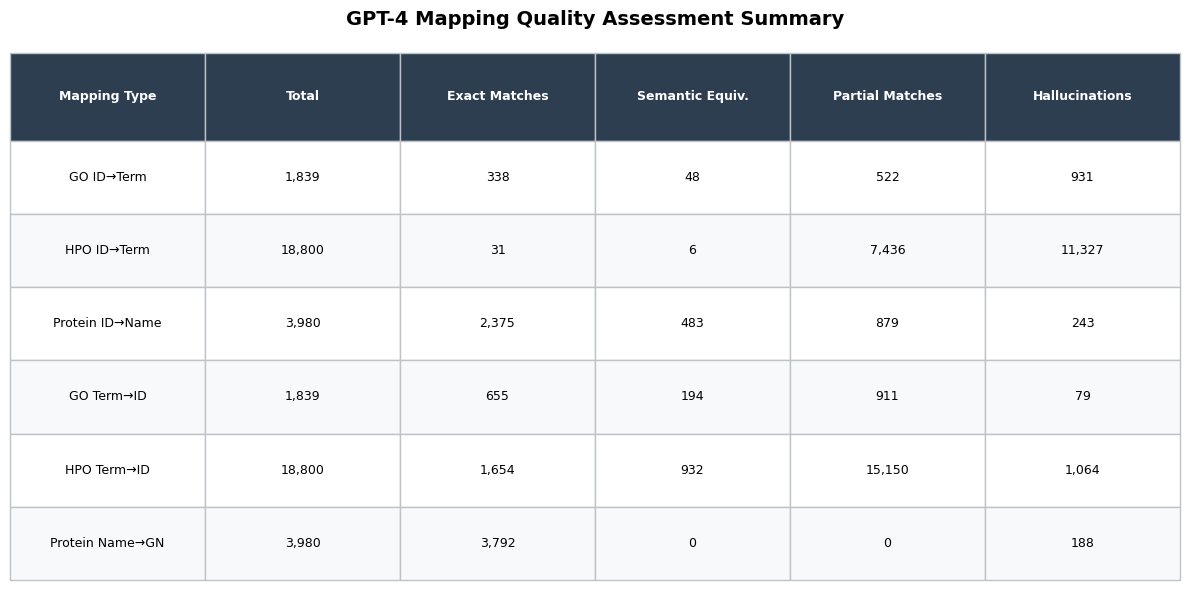

Creating quality chart...


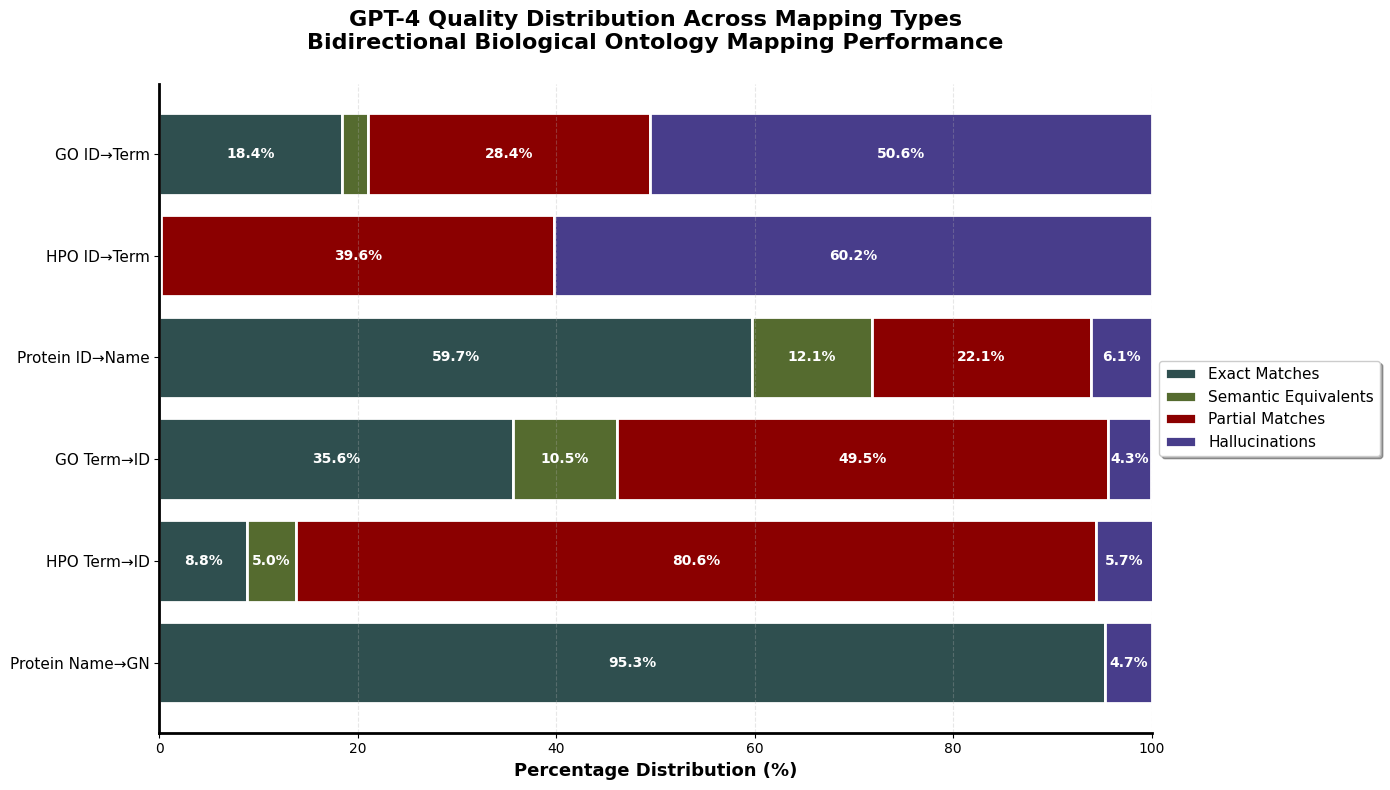

Finding example cases...
Generating detailed quality report...
MAPPING QUALITY ASSESSMENT REPORT

📊 QUALITY BREAKDOWN SUMMARY:
Mapping              Exact    Semantic   Partial  Halluc. 
-----------------------------------------------------------------
GO ID→Term             18.4%      2.6%    28.4%    50.6%
HPO ID→Term             0.2%      0.0%    39.6%    60.2%
Protein ID→Name        59.7%     12.1%    22.1%     6.1%
GO Term→ID             35.6%     10.5%    49.5%     4.3%
HPO Term→ID             8.8%      5.0%    80.6%     5.7%
Protein Name→GN        95.3%      0.0%     0.0%     4.7%

🎯 KEY QUALITY INSIGHTS:
• Highest exact match rate: Protein Name→GN (95.3%)
• Highest hallucination rate: HPO ID→Term (60.2%)
• Overall exact match accuracy: 18.0% (8,845/49,238)

📝 EXAMPLE CASES:

GO ID→Term:
  Semantic Equivalent:
    1. 'I band' → 'I-band' (similarity: 1.00)
    2. 'brush border membrane' → 'brush border' (similarity: 0.73)
  Partial Match:
    1. 'tight junction' → 'occluding junct

In [20]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
import re
from collections import Counter
import matplotlib.pyplot as plt

def load_mapping_data():
    """Load all bidirectional mapping results"""
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Gpt Id to terms/go_term_mapping_results.csv')
    hpo_term_results = pd.read_csv('Gpt Id to terms/hpo_term_mapping_results.csv')
    protein_name_results = pd.read_csv('Gpt Id to terms/gene_protein_mapping_results.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Gpt term to id/go_id_mapping_results.csv')
    hpo_id_results = pd.read_csv('Gpt term to id/hpo_id_mapping_results.csv')
    protein_gn_results = pd.read_csv('Gpt term to id/protein_gn_mapping_results.csv')
    

    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def normalize_text(text):
    """Normalize text for comparison"""
    if pd.isna(text):
        return ""
    # Convert to lowercase, remove extra spaces, punctuation
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def calculate_similarity(text1, text2):
    """Calculate similarity between two texts"""
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    
    if not norm1 or not norm2:
        return 0.0
    
    return SequenceMatcher(None, norm1, norm2).ratio()

def check_semantic_equivalence(original, generated, threshold=0.6):
    """Check if terms are semantically equivalent using keyword overlap"""
    
    norm_orig = normalize_text(original)
    norm_gen = normalize_text(generated)
    
    if not norm_orig or not norm_gen:
        return False
    
    # Split into words
    orig_words = set(norm_orig.split())
    gen_words = set(norm_gen.split())
    
    # Remove common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'of', 'in', 'on', 'at', 'to', 'for', 'with'}
    orig_words = orig_words - stop_words
    gen_words = gen_words - stop_words
    
    if not orig_words or not gen_words:
        return False
    
    # Calculate Jaccard similarity
    intersection = len(orig_words & gen_words)
    union = len(orig_words | gen_words)
    jaccard = intersection / union if union > 0 else 0
    
    return jaccard >= threshold

def is_valid_biological_term(term):
    """Check if a term looks like a valid biological term"""
    if pd.isna(term) or not str(term).strip():
        return False
    
    term_str = str(term).strip()
    
    # Check for obvious hallucinations/invalid patterns
    invalid_patterns = [
        r'^[0-9]+$',  # Just numbers
        r'^[A-Z]{10,}$',  # Long strings of capitals (likely gibberish)
        r'^\s*$',  # Empty or whitespace
        r'^[^a-zA-Z]*$',  # No letters at all
        r'(.)\1{4,}',  # Repeated characters (aaaaa)
    ]
    
    for pattern in invalid_patterns:
        if re.search(pattern, term_str):
            return False
    
    return True

def is_valid_ontology_id(ontology_id, ontology_type):
    """Check if an ID follows the correct ontology format"""
    if pd.isna(ontology_id):
        return False
    
    id_str = str(ontology_id).strip()
    
    patterns = {
        'GO': r'^GO:\d{7}$',
        'HPO': r'^HP:\d{7}$',
        'UniProt': r'^[A-Z0-9]+_[A-Z]+$'  # Basic UniProt pattern
    }
    
    if ontology_type in patterns:
        return bool(re.match(patterns[ontology_type], id_str))
    
    return len(id_str) > 0  # Basic check for other types

def assess_mapping_quality(df, original_col, generated_col, mapping_type='term'):
    """Assess the quality of mappings in a dataframe"""
    
    results = []
    
    for idx, row in df.iterrows():
        original = row[original_col]
        generated = row[generated_col]
        is_match = row.get('match', 0) == 1
        
        assessment = {
            'index': idx,
            'original': original,
            'generated': generated,
            'is_exact_match': is_match
        }
        
        if is_match:
            assessment['quality_category'] = 'Exact Match'
            assessment['similarity_score'] = 1.0
        else:
            # Assess non-matching cases
            if mapping_type == 'term':
                # For term generation (ID → Term)
                if not is_valid_biological_term(generated):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                elif check_semantic_equivalence(original, generated):
                    assessment['quality_category'] = 'Semantic Equivalent'
                    assessment['similarity_score'] = calculate_similarity(original, generated)
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
            else:
                # For ID generation (Term → ID)
                ontology_type = 'GO' if 'GO:' in str(original) else 'HPO' if 'HP:' in str(original) else 'UniProt'
                
                if not is_valid_ontology_id(generated, ontology_type):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.8:
                        assessment['quality_category'] = 'Semantic Equivalent'
                        assessment['similarity_score'] = similarity
                    elif similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
        
        results.append(assessment)
    
    return pd.DataFrame(results)

def analyze_all_mappings(data):
    """Analyze quality for all mapping directions"""
    
    quality_results = {}
    
    # ID → Term mappings
    print("Analyzing ID → Term mappings...")
    
    # GO ID → Term
    go_term_quality = assess_mapping_quality(
        data['go_id_to_term'], 'go_term', 'new_go_term', 'term'
    )
    quality_results['GO ID→Term'] = go_term_quality
    
    # HPO ID → Term
    hpo_term_quality = assess_mapping_quality(
        data['hpo_id_to_term'], 'hpo_term', 'new_hpo_term', 'term'
    )
    quality_results['HPO ID→Term'] = hpo_term_quality
    
    # Protein ID → Name
    protein_name_quality = assess_mapping_quality(
        data['protein_id_to_name'], 'protein_name', 'new_protein_name', 'term'
    )
    quality_results['Protein ID→Name'] = protein_name_quality
    
    # Term → ID mappings
    print("Analyzing Term → ID mappings...")
    
    # GO Term → ID
    go_id_quality = assess_mapping_quality(
        data['go_term_to_id'], 'go_id', 'newgoid', 'id'
    )
    quality_results['GO Term→ID'] = go_id_quality
    
    # HPO Term → ID
    hpo_id_quality = assess_mapping_quality(
        data['hpo_term_to_id'], 'hpo_id', 'newhpoid', 'id'
    )
    quality_results['HPO Term→ID'] = hpo_id_quality
    
    # Protein Name → GN
    protein_gn_quality = assess_mapping_quality(
        data['protein_name_to_gn'], 'GN', 'newGN', 'id'
    )
    quality_results['Protein Name→GN'] = protein_gn_quality
    
    return quality_results

def create_quality_summary_table(quality_results):
    """Create summary table for quality assessment"""
    
    summary_data = []
    
    for mapping_name, quality_df in quality_results.items():
        category_counts = quality_df['quality_category'].value_counts()
        total = len(quality_df)
        
        summary = {
            'Mapping': mapping_name,
            'Total': total,
            'Exact Matches': category_counts.get('Exact Match', 0),
            'Semantic Equivalents': category_counts.get('Semantic Equivalent', 0),
            'Partial Matches': category_counts.get('Partial Match', 0),
            'Hallucinations': category_counts.get('Hallucination', 0),
            'Exact Match %': round(category_counts.get('Exact Match', 0) / total * 100, 1),
            'Semantic Equivalent %': round(category_counts.get('Semantic Equivalent', 0) / total * 100, 1),
            'Partial Match %': round(category_counts.get('Partial Match', 0) / total * 100, 1),
            'Hallucination %': round(category_counts.get('Hallucination', 0) / total * 100, 1)
        }
        summary_data.append(summary)
    
    return pd.DataFrame(summary_data)

def create_quality_table_image(summary_df):
    """Create a clean, simple table image"""
    
    # Create figure with clean white background
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare data for table - only counts, no percentages
    table_data = []
    headers = ['Mapping Type', 'Total', 'Exact Matches', 'Semantic Equiv.', 'Partial Matches', 'Hallucinations']
    
    for _, row in summary_df.iterrows():
        table_row = [
            row['Mapping'],
            f"{row['Total']:,}",
            f"{row['Exact Matches']:,}",
            f"{row['Semantic Equivalents']:,}",
            f"{row['Partial Matches']:,}",
            f"{row['Hallucinations']:,}"
        ]
        table_data.append(table_row)
    
    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.3, 2.2)
    
    # Header styling
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#2C3E50')
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(0, i)].set_height(0.12)
    
    # Row styling with simple alternating colors
    colors = ['#F8F9FA', '#FFFFFF']
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_facecolor(colors[i % 2])
            table[(i, j)].set_height(0.1)
    
    # Add borders
    for key, cell in table.get_celld().items():
        cell.set_linewidth(1)
        cell.set_edgecolor('#BDC3C7')
    
    plt.title('GPT-4 Mapping Quality Assessment Summary', 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    return table

def find_interesting_examples(quality_results):
    """Find interesting examples for each quality category"""
    
    examples = {}
    
    for mapping_name, quality_df in quality_results.items():
        examples[mapping_name] = {}
        
        for category in ['Semantic Equivalent', 'Partial Match', 'Hallucination']:
            category_examples = quality_df[quality_df['quality_category'] == category].head(3)
            examples[mapping_name][category] = category_examples[['original', 'generated', 'similarity_score']].to_dict('records')
    
    return examples

def print_quality_report(summary_df, examples):
    """Print comprehensive quality assessment report"""
    
    print("="*80)
    print("MAPPING QUALITY ASSESSMENT REPORT")
    print("="*80)
    
    print(f"\n📊 QUALITY BREAKDOWN SUMMARY:")
    print(f"{'Mapping':<20} {'Exact':<8} {'Semantic':<10} {'Partial':<8} {'Halluc.':<8}")
    print("-" * 65)
    
    for _, row in summary_df.iterrows():
        print(f"{row['Mapping']:<20} {row['Exact Match %']:>6.1f}%  {row['Semantic Equivalent %']:>7.1f}%  {row['Partial Match %']:>6.1f}%  {row['Hallucination %']:>6.1f}%")
    
    print(f"\n🎯 KEY QUALITY INSIGHTS:")
    
    # Best performing mapping
    best_exact = summary_df.loc[summary_df['Exact Match %'].idxmax()]
    print(f"• Highest exact match rate: {best_exact['Mapping']} ({best_exact['Exact Match %']:.1f}%)")
    
    # Most problematic mapping
    worst_halluc = summary_df.loc[summary_df['Hallucination %'].idxmax()]
    print(f"• Highest hallucination rate: {worst_halluc['Mapping']} ({worst_halluc['Hallucination %']:.1f}%)")
    
    # Overall statistics
    total_exact = summary_df['Exact Matches'].sum()
    total_entries = summary_df['Total'].sum()
    overall_accuracy = total_exact / total_entries * 100
    print(f"• Overall exact match accuracy: {overall_accuracy:.1f}% ({total_exact:,}/{total_entries:,})")
    
    print(f"\n📝 EXAMPLE CASES:")
    
    for mapping_name, mapping_examples in examples.items():
        print(f"\n{mapping_name}:")
        
        for category, cases in mapping_examples.items():
            if cases:
                print(f"  {category}:")
                for i, case in enumerate(cases[:2], 1):  # Show top 2 examples
                    print(f"    {i}. '{case['original']}' → '{case['generated']}' (similarity: {case['similarity_score']:.2f})")

def create_quality_chart(summary_df):
    """Create an appealing horizontal stacked bar chart with percentages"""
    
    # Set clean style
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data - convert to percentages
    mappings = summary_df['Mapping'].tolist()
    exact_pct = summary_df['Exact Match %'].tolist()
    semantic_pct = summary_df['Semantic Equivalent %'].tolist()
    partial_pct = summary_df['Partial Match %'].tolist()
    halluc_pct = summary_df['Hallucination %'].tolist()
    
    # Bright, vibrant colors
    colors = ['#2F4F4F', '#556B2F', '#8B0000', '#483D8B']  # Bright red, bright green, bright orange, bright pink
    
    # Create horizontal stacked bars
    y_pos = range(len(mappings))
    
    # Create bars from left to right
    bars1 = ax.barh(y_pos, exact_pct, label='Exact Matches', color=colors[0], edgecolor='white', linewidth=2)
    bars2 = ax.barh(y_pos, semantic_pct, left=exact_pct, label='Semantic Equivalents', color=colors[1], edgecolor='white', linewidth=2)
    
    # Calculate left position for partial matches
    left_partial = [exact_pct[i] + semantic_pct[i] for i in range(len(mappings))]
    bars3 = ax.barh(y_pos, partial_pct, left=left_partial, label='Partial Matches', color=colors[2], edgecolor='white', linewidth=2)
    
    # Calculate left position for hallucinations
    left_halluc = [left_partial[i] + partial_pct[i] for i in range(len(mappings))]
    bars4 = ax.barh(y_pos, halluc_pct, left=left_halluc, label='Hallucinations', color=colors[3], edgecolor='white', linewidth=2)
    
    # Add percentage labels on bars
    def add_percentage_labels(bars, values, left_values=None):
        for i, (bar, value) in enumerate(zip(bars, values)):
            if value > 3:  # Only show label if segment is big enough
                if left_values:
                    x_pos = left_values[i] + value/2
                else:
                    x_pos = value/2
                ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{value:.1f}%',
                       ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # Add labels to each segment
    add_percentage_labels(bars1, exact_pct)
    add_percentage_labels(bars2, semantic_pct, exact_pct)
    add_percentage_labels(bars3, partial_pct, left_partial)
    add_percentage_labels(bars4, halluc_pct, left_halluc)
    
    # Customize the chart
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mappings, fontsize=11)
    ax.set_xlabel('Percentage Distribution (%)', fontsize=13, fontweight='bold')
    ax.set_title('GPT-4 Quality Distribution Across Mapping Types\nBidirectional Biological Ontology Mapping Performance', 
                 fontsize=16, fontweight='bold', pad=25)
    
    # Set x-axis to 0-100%
    ax.set_xlim(0, 100)
    
    # Remove grid and clean up axes
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Add legend with better positioning
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, frameon=True, 
              fancybox=True, shadow=True)
    
    # Add vertical grid lines for better readability
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    # Invert y-axis to have first mapping at top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to run quality assessment"""
    
    print("Loading mapping data...")
    data = load_mapping_data()
    
    print("Analyzing mapping quality...")
    quality_results = analyze_all_mappings(data)
    
    print("Creating quality summary table...")
    summary_df = create_quality_summary_table(quality_results)
    
    print("Creating table image...")
    create_quality_table_image(summary_df)
    
    print("Creating quality chart...")
    create_quality_chart(summary_df)
    
    print("Finding example cases...")
    examples = find_interesting_examples(quality_results)
    
    print("Generating detailed quality report...")
    print_quality_report(summary_df, examples)
    
    return quality_results, summary_df, examples

# Run the quality assessment
if __name__ == "__main__":
    quality_results, summary, examples = main()

Loading Llama 3.1 70B mapping data...
Analyzing mapping quality...
Analyzing ID → Term mappings...
Analyzing Term → ID mappings...
Creating quality summary table...
Creating table image...


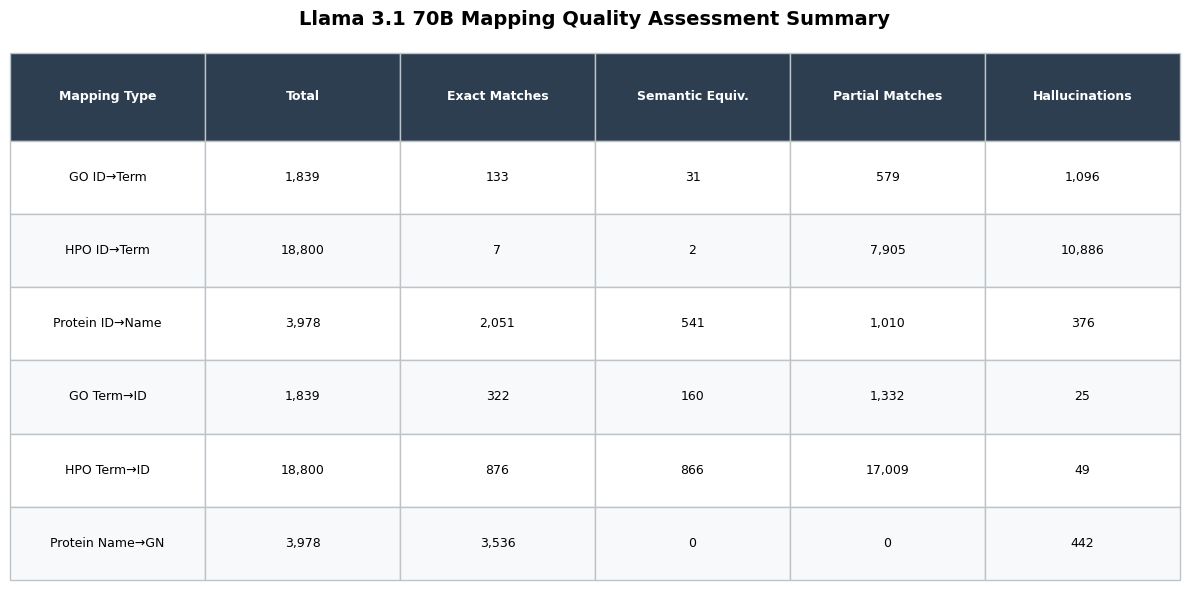

Creating quality chart...


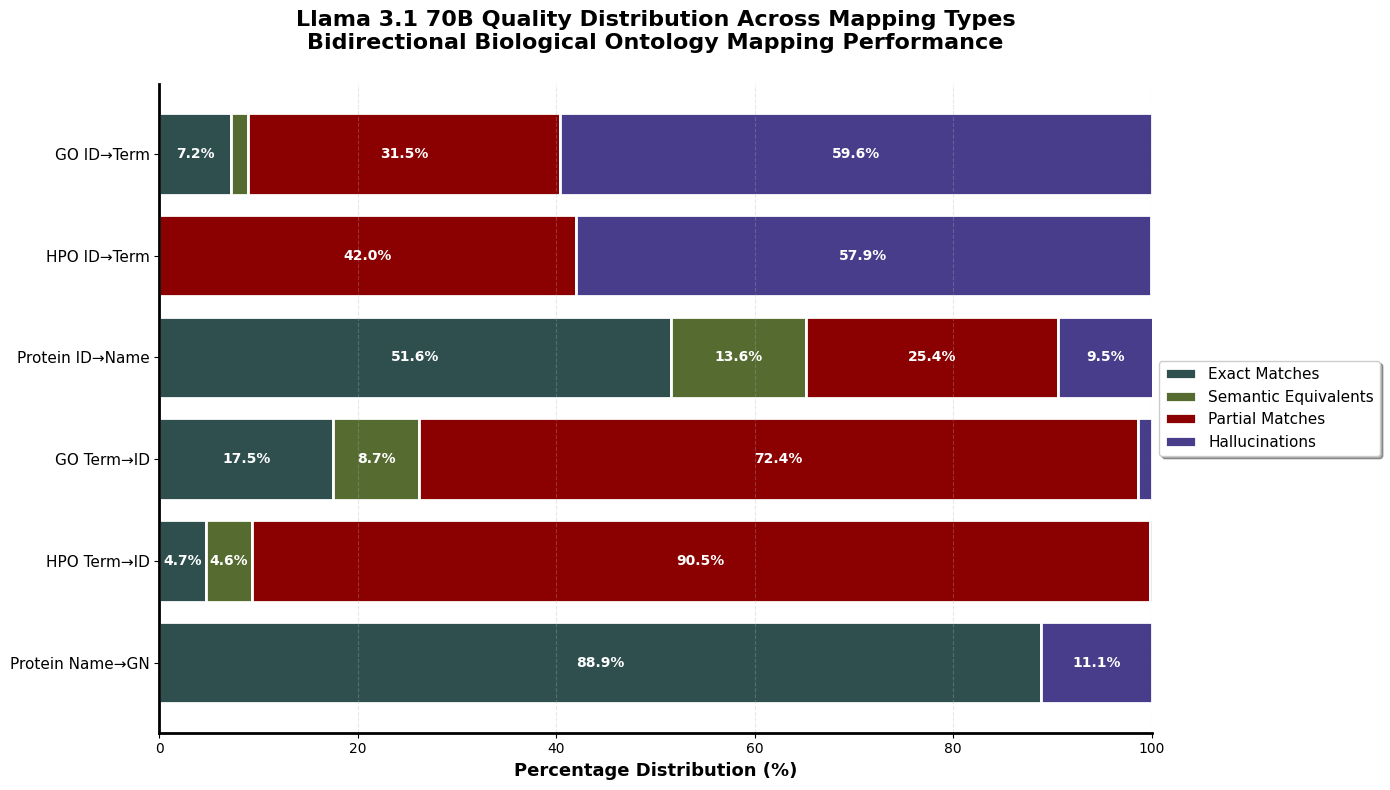

Finding example cases...
Generating detailed quality report...
LLAMA 3.1 70B MAPPING QUALITY ASSESSMENT REPORT

📊 QUALITY BREAKDOWN SUMMARY:
Mapping              Exact    Semantic   Partial  Halluc. 
-----------------------------------------------------------------
GO ID→Term              7.2%      1.7%    31.5%    59.6%
HPO ID→Term             0.0%      0.0%    42.0%    57.9%
Protein ID→Name        51.6%     13.6%    25.4%     9.5%
GO Term→ID             17.5%      8.7%    72.4%     1.4%
HPO Term→ID             4.7%      4.6%    90.5%     0.3%
Protein Name→GN        88.9%      0.0%     0.0%    11.1%

🎯 KEY QUALITY INSIGHTS:
• Highest exact match rate: Protein Name→GN (88.9%)
• Highest hallucination rate: GO ID→Term (59.6%)
• Overall exact match accuracy: 14.1% (6,925/49,234)

📝 EXAMPLE CASES:

GO ID→Term:
  Semantic Equivalent:
    1. 'mitotic spindle' → 'mitotic spindle organization' (similarity: 0.70)
    2. 'pore complex' → 'pore complex assembly' (similarity: 0.73)
  Partial Match

In [29]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
import re
from collections import Counter
import matplotlib.pyplot as plt

def load_mapping_data():
    """Load all bidirectional mapping results for Llama 3.1 70B"""
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_go_results_final.csv')
    hpo_term_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_hpo_id_term_results_final.csv')
    protein_name_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_gene_protein_v2_results_final.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_term_to_id_results_final.csv')
    hpo_id_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_hpo_term_to_id_results_final.csv')
    protein_gn_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_protein_to_gene_results_final.csv')
      

    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def normalize_text(text):
    """Normalize text for comparison"""
    if pd.isna(text):
        return ""
    # Convert to lowercase, remove extra spaces, punctuation
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def calculate_similarity(text1, text2):
    """Calculate similarity between two texts"""
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    
    if not norm1 or not norm2:
        return 0.0
    
    return SequenceMatcher(None, norm1, norm2).ratio()

def check_semantic_equivalence(original, generated, threshold=0.6):
    """Check if terms are semantically equivalent using keyword overlap"""
    
    norm_orig = normalize_text(original)
    norm_gen = normalize_text(generated)
    
    if not norm_orig or not norm_gen:
        return False
    
    # Split into words
    orig_words = set(norm_orig.split())
    gen_words = set(norm_gen.split())
    
    # Remove common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'of', 'in', 'on', 'at', 'to', 'for', 'with'}
    orig_words = orig_words - stop_words
    gen_words = gen_words - stop_words
    
    if not orig_words or not gen_words:
        return False
    
    # Calculate Jaccard similarity
    intersection = len(orig_words & gen_words)
    union = len(orig_words | gen_words)
    jaccard = intersection / union if union > 0 else 0
    
    return jaccard >= threshold

def is_valid_biological_term(term):
    """Check if a term looks like a valid biological term"""
    if pd.isna(term) or not str(term).strip():
        return False
    
    term_str = str(term).strip()
    
    # Check for obvious hallucinations/invalid patterns
    invalid_patterns = [
        r'^[0-9]+$',  # Just numbers
        r'^[A-Z]{10,}$',  # Long strings of capitals (likely gibberish)
        r'^\s*$',  # Empty or whitespace
        r'^[^a-zA-Z]*$',  # No letters at all
        r'(.)\1{4,}',  # Repeated characters (aaaaa)
    ]
    
    for pattern in invalid_patterns:
        if re.search(pattern, term_str):
            return False
    
    return True

def is_valid_ontology_id(ontology_id, ontology_type):
    """Check if an ID follows the correct ontology format"""
    if pd.isna(ontology_id):
        return False
    
    id_str = str(ontology_id).strip()
    
    patterns = {
        'GO': r'^GO:\d{7}$',
        'HPO': r'^HP:\d{7}$',
        'UniProt': r'^[A-Z0-9]+_[A-Z]+$'  # Basic UniProt pattern
    }
    
    if ontology_type in patterns:
        return bool(re.match(patterns[ontology_type], id_str))
    
    return len(id_str) > 0  # Basic check for other types

def assess_mapping_quality(df, original_col, generated_col, mapping_type='term'):
    """Assess the quality of mappings in a dataframe"""
    
    results = []
    
    for idx, row in df.iterrows():
        original = row[original_col]
        generated = row[generated_col]
        is_match = row.get('match_result', 0) == 1
        
        assessment = {
            'index': idx,
            'original': original,
            'generated': generated,
            'is_exact_match': is_match
        }
        
        if is_match:
            assessment['quality_category'] = 'Exact Match'
            assessment['similarity_score'] = 1.0
        else:
            # Assess non-matching cases
            if mapping_type == 'term':
                # For term generation (ID → Term)
                if not is_valid_biological_term(generated):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                elif check_semantic_equivalence(original, generated):
                    assessment['quality_category'] = 'Semantic Equivalent'
                    assessment['similarity_score'] = calculate_similarity(original, generated)
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
            else:
                # For ID generation (Term → ID)
                ontology_type = 'GO' if 'GO:' in str(original) else 'HPO' if 'HP:' in str(original) else 'UniProt'
                
                if not is_valid_ontology_id(generated, ontology_type):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.8:
                        assessment['quality_category'] = 'Semantic Equivalent'
                        assessment['similarity_score'] = similarity
                    elif similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
        
        results.append(assessment)
    
    return pd.DataFrame(results)

def analyze_all_mappings(data):
    """Analyze quality for all mapping directions"""
    
    quality_results = {}
    
    # ID → Term mappings
    print("Analyzing ID → Term mappings...")
    
    # GO ID → Term
    go_term_quality = assess_mapping_quality(
        data['go_id_to_term'], 'go_term', 'newgoterm', 'term'
    )
    quality_results['GO ID→Term'] = go_term_quality
    
    # HPO ID → Term
    hpo_term_quality = assess_mapping_quality(
        data['hpo_id_to_term'], 'hpo_term', 'new_hpo_term', 'term'
    )
    quality_results['HPO ID→Term'] = hpo_term_quality
    
    # Protein ID → Name
    protein_name_quality = assess_mapping_quality(
        data['protein_id_to_name'], 'protein_name', 'new_protein_name', 'term'
    )
    quality_results['Protein ID→Name'] = protein_name_quality
    
    # Term → ID mappings
    print("Analyzing Term → ID mappings...")
    
    # GO Term → ID
    go_id_quality = assess_mapping_quality(
        data['go_term_to_id'], 'go_id', 'new_go_id', 'id'
    )
    quality_results['GO Term→ID'] = go_id_quality
    
    # HPO Term → ID
    hpo_id_quality = assess_mapping_quality(
        data['hpo_term_to_id'], 'hpo_id', 'new_hpo_id', 'id'
    )
    quality_results['HPO Term→ID'] = hpo_id_quality
    
    # Protein Name → GN
    protein_gn_quality = assess_mapping_quality(
        data['protein_name_to_gn'], 'GN', 'new_gene_symbol', 'id'
    )
    quality_results['Protein Name→GN'] = protein_gn_quality
    
    return quality_results

def create_quality_summary_table(quality_results):
    """Create summary table for quality assessment"""
    
    summary_data = []
    
    for mapping_name, quality_df in quality_results.items():
        category_counts = quality_df['quality_category'].value_counts()
        total = len(quality_df)
        
        summary = {
            'Mapping': mapping_name,
            'Total': total,
            'Exact Matches': category_counts.get('Exact Match', 0),
            'Semantic Equivalents': category_counts.get('Semantic Equivalent', 0),
            'Partial Matches': category_counts.get('Partial Match', 0),
            'Hallucinations': category_counts.get('Hallucination', 0),
            'Exact Match %': round(category_counts.get('Exact Match', 0) / total * 100, 1),
            'Semantic Equivalent %': round(category_counts.get('Semantic Equivalent', 0) / total * 100, 1),
            'Partial Match %': round(category_counts.get('Partial Match', 0) / total * 100, 1),
            'Hallucination %': round(category_counts.get('Hallucination', 0) / total * 100, 1)
        }
        summary_data.append(summary)
    
    return pd.DataFrame(summary_data)

def create_quality_table_image(summary_df):
    """Create a clean, simple table image"""
    
    # Create figure with clean white background
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare data for table - only counts, no percentages
    table_data = []
    headers = ['Mapping Type', 'Total', 'Exact Matches', 'Semantic Equiv.', 'Partial Matches', 'Hallucinations']
    
    for _, row in summary_df.iterrows():
        table_row = [
            row['Mapping'],
            f"{row['Total']:,}",
            f"{row['Exact Matches']:,}",
            f"{row['Semantic Equivalents']:,}",
            f"{row['Partial Matches']:,}",
            f"{row['Hallucinations']:,}"
        ]
        table_data.append(table_row)
    
    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.3, 2.2)
    
    # Header styling
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#2C3E50')
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(0, i)].set_height(0.12)
    
    # Row styling with simple alternating colors
    colors = ['#F8F9FA', '#FFFFFF']
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_facecolor(colors[i % 2])
            table[(i, j)].set_height(0.1)
    
    # Add borders
    for key, cell in table.get_celld().items():
        cell.set_linewidth(1)
        cell.set_edgecolor('#BDC3C7')
    
    plt.title('Llama 3.1 70B Mapping Quality Assessment Summary', 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    return table

def find_interesting_examples(quality_results):
    """Find interesting examples for each quality category"""
    
    examples = {}
    
    for mapping_name, quality_df in quality_results.items():
        examples[mapping_name] = {}
        
        for category in ['Semantic Equivalent', 'Partial Match', 'Hallucination']:
            category_examples = quality_df[quality_df['quality_category'] == category].head(3)
            examples[mapping_name][category] = category_examples[['original', 'generated', 'similarity_score']].to_dict('records')
    
    return examples

def print_quality_report(summary_df, examples):
    """Print comprehensive quality assessment report"""
    
    print("="*80)
    print("LLAMA 3.1 70B MAPPING QUALITY ASSESSMENT REPORT")
    print("="*80)
    
    print(f"\n📊 QUALITY BREAKDOWN SUMMARY:")
    print(f"{'Mapping':<20} {'Exact':<8} {'Semantic':<10} {'Partial':<8} {'Halluc.':<8}")
    print("-" * 65)
    
    for _, row in summary_df.iterrows():
        print(f"{row['Mapping']:<20} {row['Exact Match %']:>6.1f}%  {row['Semantic Equivalent %']:>7.1f}%  {row['Partial Match %']:>6.1f}%  {row['Hallucination %']:>6.1f}%")
    
    print(f"\n🎯 KEY QUALITY INSIGHTS:")
    
    # Best performing mapping
    best_exact = summary_df.loc[summary_df['Exact Match %'].idxmax()]
    print(f"• Highest exact match rate: {best_exact['Mapping']} ({best_exact['Exact Match %']:.1f}%)")
    
    # Most problematic mapping
    worst_halluc = summary_df.loc[summary_df['Hallucination %'].idxmax()]
    print(f"• Highest hallucination rate: {worst_halluc['Mapping']} ({worst_halluc['Hallucination %']:.1f}%)")
    
    # Overall statistics
    total_exact = summary_df['Exact Matches'].sum()
    total_entries = summary_df['Total'].sum()
    overall_accuracy = total_exact / total_entries * 100
    print(f"• Overall exact match accuracy: {overall_accuracy:.1f}% ({total_exact:,}/{total_entries:,})")
    
    print(f"\n📝 EXAMPLE CASES:")
    
    for mapping_name, mapping_examples in examples.items():
        print(f"\n{mapping_name}:")
        
        for category, cases in mapping_examples.items():
            if cases:
                print(f"  {category}:")
                for i, case in enumerate(cases[:2], 1):  # Show top 2 examples
                    print(f"    {i}. '{case['original']}' → '{case['generated']}' (similarity: {case['similarity_score']:.2f})")

def create_quality_chart(summary_df):
    """Create an appealing horizontal stacked bar chart with percentages"""
    
    # Set clean style
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data - convert to percentages
    mappings = summary_df['Mapping'].tolist()
    exact_pct = summary_df['Exact Match %'].tolist()
    semantic_pct = summary_df['Semantic Equivalent %'].tolist()
    partial_pct = summary_df['Partial Match %'].tolist()
    halluc_pct = summary_df['Hallucination %'].tolist()
    
    # Subtle colors
    colors = ['#2F4F4F', '#556B2F', '#8B0000', '#483D8B']  # Dark slate gray, dark olive green, dark red, dark slate blue
    
    # Create horizontal stacked bars
    y_pos = range(len(mappings))
    
    # Create bars from left to right
    bars1 = ax.barh(y_pos, exact_pct, label='Exact Matches', color=colors[0], edgecolor='white', linewidth=2)
    bars2 = ax.barh(y_pos, semantic_pct, left=exact_pct, label='Semantic Equivalents', color=colors[1], edgecolor='white', linewidth=2)
    
    # Calculate left position for partial matches
    left_partial = [exact_pct[i] + semantic_pct[i] for i in range(len(mappings))]
    bars3 = ax.barh(y_pos, partial_pct, left=left_partial, label='Partial Matches', color=colors[2], edgecolor='white', linewidth=2)
    
    # Calculate left position for hallucinations
    left_halluc = [left_partial[i] + partial_pct[i] for i in range(len(mappings))]
    bars4 = ax.barh(y_pos, halluc_pct, left=left_halluc, label='Hallucinations', color=colors[3], edgecolor='white', linewidth=2)
    
    # Add percentage labels on bars
    def add_percentage_labels(bars, values, left_values=None):
        for i, (bar, value) in enumerate(zip(bars, values)):
            if value > 3:  # Only show label if segment is big enough
                if left_values:
                    x_pos = left_values[i] + value/2
                else:
                    x_pos = value/2
                ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{value:.1f}%',
                       ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # Add labels to each segment
    add_percentage_labels(bars1, exact_pct)
    add_percentage_labels(bars2, semantic_pct, exact_pct)
    add_percentage_labels(bars3, partial_pct, left_partial)
    add_percentage_labels(bars4, halluc_pct, left_halluc)
    
    # Customize the chart
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mappings, fontsize=11)
    ax.set_xlabel('Percentage Distribution (%)', fontsize=13, fontweight='bold')
    ax.set_title('Llama 3.1 70B Quality Distribution Across Mapping Types\nBidirectional Biological Ontology Mapping Performance', 
                 fontsize=16, fontweight='bold', pad=25)
    
    # Set x-axis to 0-100%
    ax.set_xlim(0, 100)
    
    # Remove grid and clean up axes
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Add legend with better positioning
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, frameon=True, 
              fancybox=True, shadow=True)
    
    # Add vertical grid lines for better readability
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    # Invert y-axis to have first mapping at top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to run quality assessment"""
    
    print("Loading Llama 3.1 70B mapping data...")
    data = load_mapping_data()
    
    print("Analyzing mapping quality...")
    quality_results = analyze_all_mappings(data)
    
    print("Creating quality summary table...")
    summary_df = create_quality_summary_table(quality_results)
    
    print("Creating table image...")
    create_quality_table_image(summary_df)
    
    print("Creating quality chart...")
    create_quality_chart(summary_df)
    
    print("Finding example cases...")
    examples = find_interesting_examples(quality_results)
    
    print("Generating detailed quality report...")
    print_quality_report(summary_df, examples)
    
    return quality_results, summary_df, examples

# Run the quality assessment
if __name__ == "__main__":
    quality_results, summary, examples = main()

Loading bidirectional mapping data...
Calculating accuracy metrics...
Creating clean bidirectional chart...


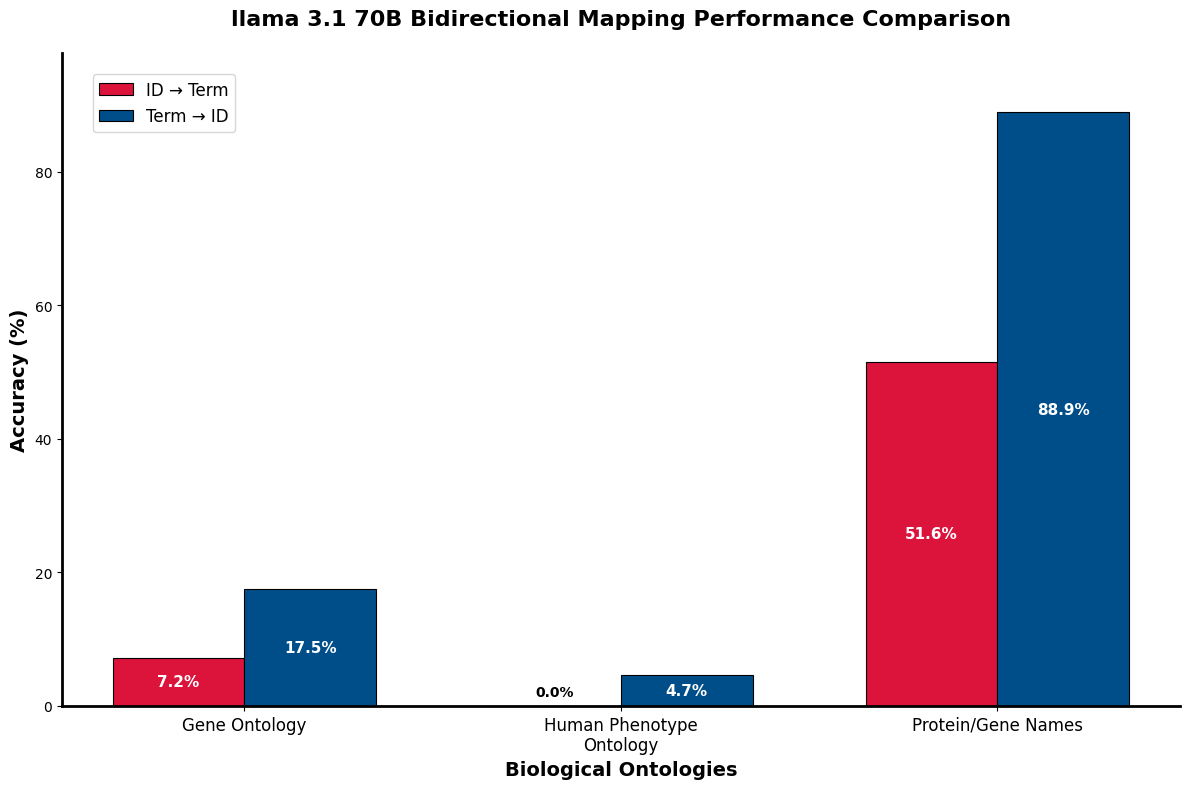


Results:
GO: ID→Term 7.2%, Term→ID 17.5%
HPO: ID→Term 0.0%, Term→ID 4.7%
Protein: ID→Term 51.6%, Term→ID 88.9%


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_mapping_data():
    """Load all bidirectional mapping results"""
    
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_go_results_final.csv')
    hpo_term_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_hpo_id_term_results_final.csv')
    protein_name_results = pd.read_csv('Llama 3.1 70 B Id to terms/llama31_70b_gene_protein_v2_results_final.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_term_to_id_results_final.csv')
    hpo_id_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_hpo_term_to_id_results_final.csv')
    protein_gn_results = pd.read_csv('Llama 3.1 70B terms to ID/llama31_70b_protein_to_gene_results_final.csv')
    
    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def calculate_accuracy_metrics(data):
    """Calculate accuracy metrics for all mapping directions"""
    
    results = {}
    
    # ID → Term accuracies
    results['GO ID→Term'] = (data['go_id_to_term']['match_result'] == 1).mean() * 100
    results['HPO ID→Term'] = (data['hpo_id_to_term']['match_result'] == 1).mean() * 100
    results['Protein ID→Name'] = (data['protein_id_to_name']['match_result'] == 1).mean() * 100
    
    # Term → ID accuracies
    results['GO Term→ID'] = (data['go_term_to_id']['match_result'] == 1).mean() * 100
    results['HPO Term→ID'] = (data['hpo_term_to_id']['match_result'] == 1).mean() * 100
    results['Protein Name→GN'] = (data['protein_name_to_gn']['match_result'] == 1).mean() * 100
    
    return results

def create_clean_bidirectional_chart(accuracy_results):
    """Create a clean bidirectional comparison chart with bright colors and borders"""
    
    # Set clean white background
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data for plotting
    ontologies = ['Gene Ontology', 'Human Phenotype\nOntology', 'Protein/Gene Names']
    id_to_term = [accuracy_results['GO ID→Term'], 
                  accuracy_results['HPO ID→Term'], 
                  accuracy_results['Protein ID→Name']]
    term_to_id = [accuracy_results['GO Term→ID'], 
                  accuracy_results['HPO Term→ID'], 
                  accuracy_results['Protein Name→GN']]
    
    x = np.arange(len(ontologies))
    width = 0.35
    
    # Bright colors with borders
    color1 = '#DC143C'  # Bright red
    color2 = '#004E89'  # Deep blue
    
    # Create bars with black borders
    bars1 = ax.bar(x - width/2, id_to_term, width, 
                   label='ID → Term', 
                   color=color1, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    bars2 = ax.bar(x + width/2, term_to_id, width, 
                   label='Term → ID', 
                   color=color2, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    # Customize plot - remove all grid lines and background elements
    ax.set_xlabel('Biological Ontologies', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('llama 3.1 70B Bidirectional Mapping Performance Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(ontologies, fontsize=12)
    ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(0.02, 0.98))
    
    # Remove all grid lines and spines except bottom and left
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Set y-axis to start from 0 with better range for small values
    max_val = max(max(id_to_term), max(term_to_id))
    if max_val < 10:
        ax.set_ylim(0, 10)  # Better range for small percentages
    else:
        ax.set_ylim(0, max_val * 1.1)
    
    # Add value labels on bars with bold text - different positioning for small values
    def add_value_labels(bars, color='white'):
        for bar in bars:
            height = bar.get_height()
            # For very small bars, place label above the bar
            if height < 2:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 5),
                           textcoords="offset points",
                           ha='center', va='bottom',
                           fontweight='bold',
                           fontsize=10,
                           color='black')
            else:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height/2),
                           ha='center', va='center',
                           fontweight='bold',
                           fontsize=11,
                           color=color)
    
    add_value_labels(bars1, 'white')
    add_value_labels(bars2, 'white')
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to create the chart"""
    
    print("Loading bidirectional mapping data...")
    data = load_mapping_data()
    
    print("Calculating accuracy metrics...")
    accuracy_results = calculate_accuracy_metrics(data)
    
    print("Creating clean bidirectional chart...")
    create_clean_bidirectional_chart(accuracy_results)
    
    # Print results for reference
    print(f"\nResults:")
    print(f"GO: ID→Term {accuracy_results['GO ID→Term']:.1f}%, Term→ID {accuracy_results['GO Term→ID']:.1f}%")
    print(f"HPO: ID→Term {accuracy_results['HPO ID→Term']:.1f}%, Term→ID {accuracy_results['HPO Term→ID']:.1f}%")
    print(f"Protein: ID→Term {accuracy_results['Protein ID→Name']:.1f}%, Term→ID {accuracy_results['Protein Name→GN']:.1f}%")

# Run the analysis
if __name__ == "__main__":
    main()

Loading bidirectional mapping data...
Calculating accuracy metrics...
Creating clean bidirectional chart...


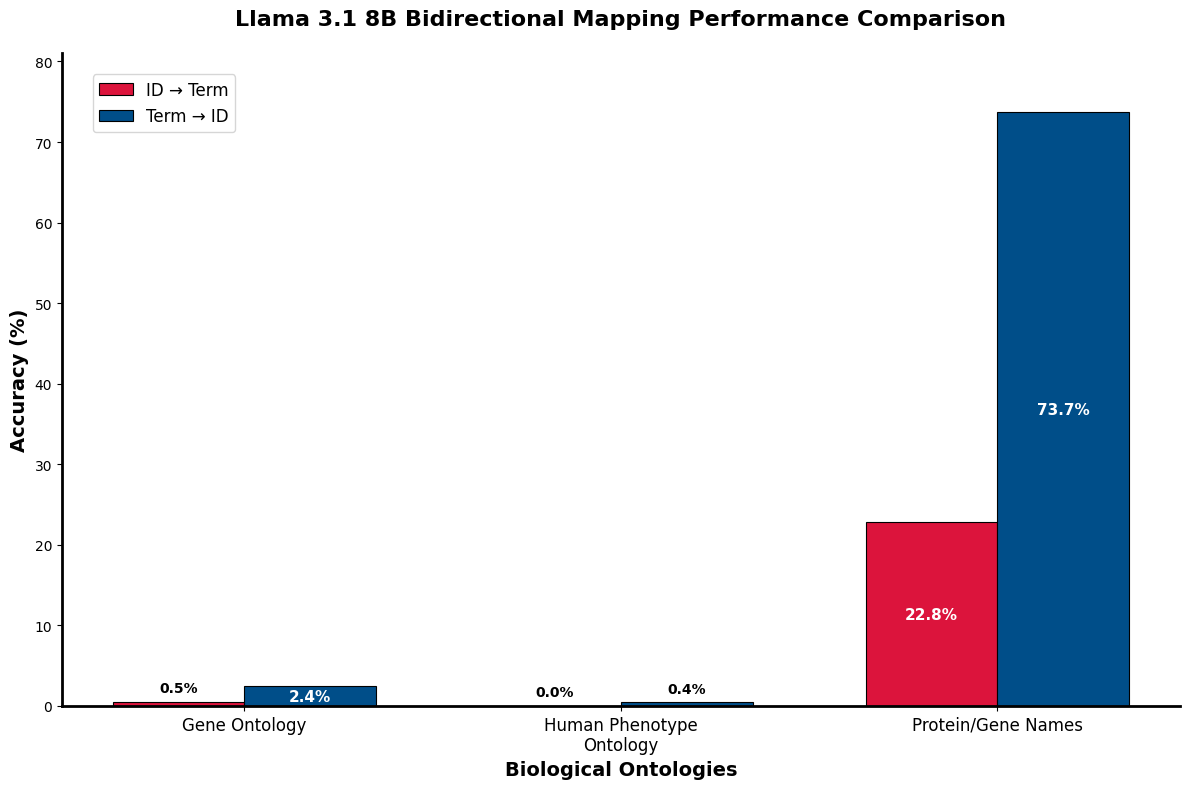


Results:
GO: ID→Term 0.5%, Term→ID 2.4%
HPO: ID→Term 0.0%, Term→ID 0.4%
Protein: ID→Term 22.8%, Term→ID 73.7%


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_mapping_data():
    """Load all bidirectional mapping results"""
    
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_go_results_final.csv')
    hpo_term_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_hpo_id_term_results_final.csv')
    protein_name_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_gene_protein_results_final.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Llama 3.1 8B terms to Id/llama31_8b_go_term_id_results_final.csv')
    hpo_id_results = pd.read_csv('Llama 3.1 8B terms to Id/llama31_8b_hpo_term_id_results_final.csv')
    protein_gn_results = pd.read_csv('Llama 3.1 8B terms to Id/ZS_protein_gn_llama_results_final.csv')
    
    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def calculate_accuracy_metrics(data):
    """Calculate accuracy metrics for all mapping directions"""
    
    results = {}
    
    # ID → Term accuracies
    results['GO ID→Term'] = (data['go_id_to_term']['match_result'] == 1).mean() * 100
    results['HPO ID→Term'] = (data['hpo_id_to_term']['match_result'] == 1).mean() * 100
    results['Protein ID→Name'] = (data['protein_id_to_name']['match_result'] == 1).mean() * 100
    
    # Term → ID accuracies
    results['GO Term→ID'] = (data['go_term_to_id']['match_result'] == 1).mean() * 100
    results['HPO Term→ID'] = (data['hpo_term_to_id']['match_result'] == 1).mean() * 100
    results['Protein Name→GN'] = (data['protein_name_to_gn']['match_result'] == 1).mean() * 100
    
    return results

def create_clean_bidirectional_chart(accuracy_results):
    """Create a clean bidirectional comparison chart with bright colors and borders"""
    
    # Set clean white background
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data for plotting
    ontologies = ['Gene Ontology', 'Human Phenotype\nOntology', 'Protein/Gene Names']
    id_to_term = [accuracy_results['GO ID→Term'], 
                  accuracy_results['HPO ID→Term'], 
                  accuracy_results['Protein ID→Name']]
    term_to_id = [accuracy_results['GO Term→ID'], 
                  accuracy_results['HPO Term→ID'], 
                  accuracy_results['Protein Name→GN']]
    
    x = np.arange(len(ontologies))
    width = 0.35
    
    # Bright colors with borders
    color1 = '#DC143C'  # Bright red
    color2 = '#004E89'  # Deep blue
    
    # Create bars with black borders
    bars1 = ax.bar(x - width/2, id_to_term, width, 
                   label='ID → Term', 
                   color=color1, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    bars2 = ax.bar(x + width/2, term_to_id, width, 
                   label='Term → ID', 
                   color=color2, 
                   edgecolor='black', 
                   linewidth=0.8)
    
    # Customize plot - remove all grid lines and background elements
    ax.set_xlabel('Biological Ontologies', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('Llama 3.1 8B Bidirectional Mapping Performance Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(ontologies, fontsize=12)
    ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(0.02, 0.98))
    
    # Remove all grid lines and spines except bottom and left
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Set y-axis to start from 0 with better range for small values
    max_val = max(max(id_to_term), max(term_to_id))
    if max_val < 10:
        ax.set_ylim(0, 10)  # Better range for small percentages
    else:
        ax.set_ylim(0, max_val * 1.1)
    
    # Add value labels on bars with bold text - different positioning for small values
    def add_value_labels(bars, color='white'):
        for bar in bars:
            height = bar.get_height()
            # For very small bars, place label above the bar
            if height < 2:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 5),
                           textcoords="offset points",
                           ha='center', va='bottom',
                           fontweight='bold',
                           fontsize=10,
                           color='black')
            else:
                ax.annotate(f'{height:.1f}%',
                           xy=(bar.get_x() + bar.get_width() / 2, height/2),
                           ha='center', va='center',
                           fontweight='bold',
                           fontsize=11,
                           color=color)
    
    add_value_labels(bars1, 'white')
    add_value_labels(bars2, 'white')
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to create the chart"""
    
    print("Loading bidirectional mapping data...")
    data = load_mapping_data()
    
    print("Calculating accuracy metrics...")
    accuracy_results = calculate_accuracy_metrics(data)
    
    print("Creating clean bidirectional chart...")
    create_clean_bidirectional_chart(accuracy_results)
    
    # Print results for reference
    print(f"\nResults:")
    print(f"GO: ID→Term {accuracy_results['GO ID→Term']:.1f}%, Term→ID {accuracy_results['GO Term→ID']:.1f}%")
    print(f"HPO: ID→Term {accuracy_results['HPO ID→Term']:.1f}%, Term→ID {accuracy_results['HPO Term→ID']:.1f}%")
    print(f"Protein: ID→Term {accuracy_results['Protein ID→Name']:.1f}%, Term→ID {accuracy_results['Protein Name→GN']:.1f}%")

# Run the analysis
if __name__ == "__main__":
    main()

Loading Llama 3.1 8B mapping data...
Analyzing mapping quality...
Analyzing ID → Term mappings...
Analyzing Term → ID mappings...
Creating quality summary table...
Creating table image...


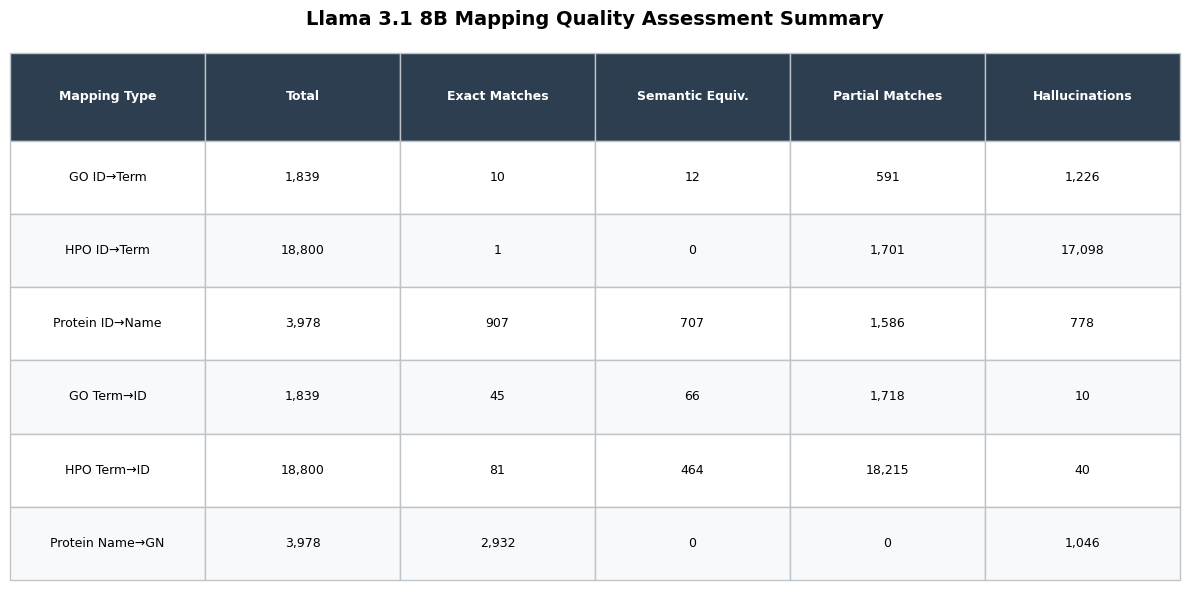

Creating quality chart...


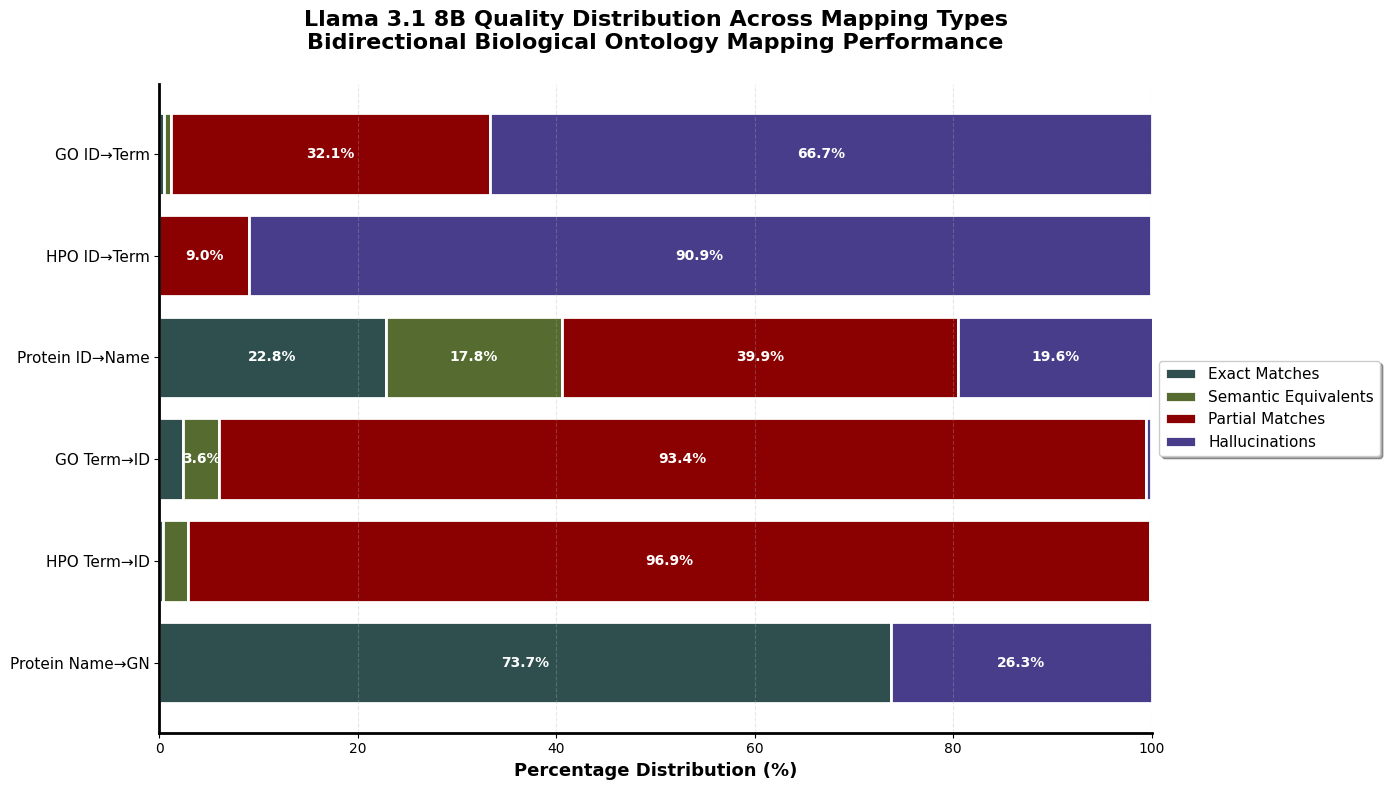

Finding example cases...
Generating detailed quality report...
LLAMA 3.1 8B MAPPING QUALITY ASSESSMENT REPORT

📊 QUALITY BREAKDOWN SUMMARY:
Mapping              Exact    Semantic   Partial  Halluc. 
-----------------------------------------------------------------
GO ID→Term              0.5%      0.7%    32.1%    66.7%
HPO ID→Term             0.0%      0.0%     9.0%    90.9%
Protein ID→Name        22.8%     17.8%    39.9%    19.6%
GO Term→ID              2.4%      3.6%    93.4%     0.5%
HPO Term→ID             0.4%      2.5%    96.9%     0.2%
Protein Name→GN        73.7%      0.0%     0.0%    26.3%

🎯 KEY QUALITY INSIGHTS:
• Highest exact match rate: Protein Name→GN (73.7%)
• Highest hallucination rate: HPO ID→Term (90.9%)
• Overall exact match accuracy: 8.1% (3,976/49,234)

📝 EXAMPLE CASES:

GO ID→Term:
  Semantic Equivalent:
    1. 'endoplasmic reticulum' → 'Endoplasmic reticulum' (similarity: 1.00)
    2. 'cytosol' → 'Cytosol' (similarity: 1.00)
  Partial Match:
    1. 'membrane' →

In [36]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
import re
from collections import Counter
import matplotlib.pyplot as plt

def load_mapping_data():
    """Load all bidirectional mapping results for Llama 3.1 8B"""
    
    # ID → Term mappings (first 3 files)
    go_term_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_go_results_final.csv')
    hpo_term_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_hpo_id_term_results_final.csv')
    protein_name_results = pd.read_csv('Llama 3.1 8B Id to terms/llama31_8b_gene_protein_results_final.csv')
    
    # Term → ID mappings (next 3 files) 
    go_id_results = pd.read_csv('Llama 3.1 8B terms to Id/llama31_8b_go_term_id_results_final.csv')
    hpo_id_results = pd.read_csv('Llama 3.1 8B terms to Id/llama31_8b_hpo_term_id_results_final.csv')
    protein_gn_results = pd.read_csv('Llama 3.1 8B terms to Id/ZS_protein_gn_llama_results_final.csv')
    
    return {
        'go_id_to_term': go_term_results,
        'hpo_id_to_term': hpo_term_results,
        'protein_id_to_name': protein_name_results,
        'go_term_to_id': go_id_results,
        'hpo_term_to_id': hpo_id_results,
        'protein_name_to_gn': protein_gn_results
    }

def normalize_text(text):
    """Normalize text for comparison"""
    if pd.isna(text):
        return ""
    # Convert to lowercase, remove extra spaces, punctuation
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def calculate_similarity(text1, text2):
    """Calculate similarity between two texts"""
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    
    if not norm1 or not norm2:
        return 0.0
    
    return SequenceMatcher(None, norm1, norm2).ratio()

def check_semantic_equivalence(original, generated, threshold=0.6):
    """Check if terms are semantically equivalent using keyword overlap"""
    
    norm_orig = normalize_text(original)
    norm_gen = normalize_text(generated)
    
    if not norm_orig or not norm_gen:
        return False
    
    # Split into words
    orig_words = set(norm_orig.split())
    gen_words = set(norm_gen.split())
    
    # Remove common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'of', 'in', 'on', 'at', 'to', 'for', 'with'}
    orig_words = orig_words - stop_words
    gen_words = gen_words - stop_words
    
    if not orig_words or not gen_words:
        return False
    
    # Calculate Jaccard similarity
    intersection = len(orig_words & gen_words)
    union = len(orig_words | gen_words)
    jaccard = intersection / union if union > 0 else 0
    
    return jaccard >= threshold

def is_valid_biological_term(term):
    """Check if a term looks like a valid biological term"""
    if pd.isna(term) or not str(term).strip():
        return False
    
    term_str = str(term).strip()
    
    # Check for obvious hallucinations/invalid patterns
    invalid_patterns = [
        r'^[0-9]+$',  # Just numbers
        r'^[A-Z]{10,}$',  # Long strings of capitals (likely gibberish)
        r'^\s*$',  # Empty or whitespace
        r'^[^a-zA-Z]*$',  # No letters at all
        r'(.)\1{4,}',  # Repeated characters (aaaaa)
    ]
    
    for pattern in invalid_patterns:
        if re.search(pattern, term_str):
            return False
    
    return True

def is_valid_ontology_id(ontology_id, ontology_type):
    """Check if an ID follows the correct ontology format"""
    if pd.isna(ontology_id):
        return False
    
    id_str = str(ontology_id).strip()
    
    patterns = {
        'GO': r'^GO:\d{7}$',
        'HPO': r'^HP:\d{7}$',
        'UniProt': r'^[A-Z0-9]+_[A-Z]+$'  # Basic UniProt pattern
    }
    
    if ontology_type in patterns:
        return bool(re.match(patterns[ontology_type], id_str))
    
    return len(id_str) > 0  # Basic check for other types

def assess_mapping_quality(df, original_col, generated_col, mapping_type='term'):
    """Assess the quality of mappings in a dataframe"""
    
    results = []
    
    for idx, row in df.iterrows():
        original = row[original_col]
        generated = row[generated_col]
        is_match = row.get('match_result', 0) == 1
        
        assessment = {
            'index': idx,
            'original': original,
            'generated': generated,
            'is_exact_match': is_match
        }
        
        if is_match:
            assessment['quality_category'] = 'Exact Match'
            assessment['similarity_score'] = 1.0
        else:
            # Assess non-matching cases
            if mapping_type == 'term':
                # For term generation (ID → Term)
                if not is_valid_biological_term(generated):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                elif check_semantic_equivalence(original, generated):
                    assessment['quality_category'] = 'Semantic Equivalent'
                    assessment['similarity_score'] = calculate_similarity(original, generated)
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
            else:
                # For ID generation (Term → ID)
                ontology_type = 'GO' if 'GO:' in str(original) else 'HPO' if 'HP:' in str(original) else 'UniProt'
                
                if not is_valid_ontology_id(generated, ontology_type):
                    assessment['quality_category'] = 'Hallucination'
                    assessment['similarity_score'] = 0.0
                else:
                    similarity = calculate_similarity(original, generated)
                    if similarity > 0.8:
                        assessment['quality_category'] = 'Semantic Equivalent'
                        assessment['similarity_score'] = similarity
                    elif similarity > 0.3:
                        assessment['quality_category'] = 'Partial Match'
                        assessment['similarity_score'] = similarity
                    else:
                        assessment['quality_category'] = 'Hallucination'
                        assessment['similarity_score'] = similarity
        
        results.append(assessment)
    
    return pd.DataFrame(results)

def analyze_all_mappings(data):
    """Analyze quality for all mapping directions"""
    
    quality_results = {}
    
    # ID → Term mappings
    print("Analyzing ID → Term mappings...")
    
    # GO ID → Term
    go_term_quality = assess_mapping_quality(
        data['go_id_to_term'], 'go_term', 'newgoterm', 'term'
    )
    quality_results['GO ID→Term'] = go_term_quality
    
    # HPO ID → Term
    hpo_term_quality = assess_mapping_quality(
        data['hpo_id_to_term'], 'hpo_term', 'new_hpo_term', 'term'
    )
    quality_results['HPO ID→Term'] = hpo_term_quality
    
    # Protein ID → Name
    protein_name_quality = assess_mapping_quality(
        data['protein_id_to_name'], 'protein_name', 'new_protein_name', 'term'
    )
    quality_results['Protein ID→Name'] = protein_name_quality
    
    # Term → ID mappings
    print("Analyzing Term → ID mappings...")
    
    # GO Term → ID
    go_id_quality = assess_mapping_quality(
        data['go_term_to_id'], 'go_id', 'newgoid', 'id'
    )
    quality_results['GO Term→ID'] = go_id_quality
    
    # HPO Term → ID
    hpo_id_quality = assess_mapping_quality(
        data['hpo_term_to_id'], 'hpo_id', 'new_hpo_id', 'id'
    )
    quality_results['HPO Term→ID'] = hpo_id_quality
    
    # Protein Name → GN
    protein_gn_quality = assess_mapping_quality(
        data['protein_name_to_gn'], 'GN', 'new_gn', 'id'
    )
    quality_results['Protein Name→GN'] = protein_gn_quality
    
    return quality_results

def create_quality_summary_table(quality_results):
    """Create summary table for quality assessment"""
    
    summary_data = []
    
    for mapping_name, quality_df in quality_results.items():
        category_counts = quality_df['quality_category'].value_counts()
        total = len(quality_df)
        
        summary = {
            'Mapping': mapping_name,
            'Total': total,
            'Exact Matches': category_counts.get('Exact Match', 0),
            'Semantic Equivalents': category_counts.get('Semantic Equivalent', 0),
            'Partial Matches': category_counts.get('Partial Match', 0),
            'Hallucinations': category_counts.get('Hallucination', 0),
            'Exact Match %': round(category_counts.get('Exact Match', 0) / total * 100, 1),
            'Semantic Equivalent %': round(category_counts.get('Semantic Equivalent', 0) / total * 100, 1),
            'Partial Match %': round(category_counts.get('Partial Match', 0) / total * 100, 1),
            'Hallucination %': round(category_counts.get('Hallucination', 0) / total * 100, 1)
        }
        summary_data.append(summary)
    
    return pd.DataFrame(summary_data)

def create_quality_table_image(summary_df):
    """Create a clean, simple table image"""
    
    # Create figure with clean white background
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare data for table - only counts, no percentages
    table_data = []
    headers = ['Mapping Type', 'Total', 'Exact Matches', 'Semantic Equiv.', 'Partial Matches', 'Hallucinations']
    
    for _, row in summary_df.iterrows():
        table_row = [
            row['Mapping'],
            f"{row['Total']:,}",
            f"{row['Exact Matches']:,}",
            f"{row['Semantic Equivalents']:,}",
            f"{row['Partial Matches']:,}",
            f"{row['Hallucinations']:,}"
        ]
        table_data.append(table_row)
    
    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.3, 2.2)
    
    # Header styling
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#2C3E50')
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(0, i)].set_height(0.12)
    
    # Row styling with simple alternating colors
    colors = ['#F8F9FA', '#FFFFFF']
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            table[(i, j)].set_facecolor(colors[i % 2])
            table[(i, j)].set_height(0.1)
    
    # Add borders
    for key, cell in table.get_celld().items():
        cell.set_linewidth(1)
        cell.set_edgecolor('#BDC3C7')
    
    plt.title('Llama 3.1 8B Mapping Quality Assessment Summary', 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    return table

def find_interesting_examples(quality_results):
    """Find interesting examples for each quality category"""
    
    examples = {}
    
    for mapping_name, quality_df in quality_results.items():
        examples[mapping_name] = {}
        
        for category in ['Semantic Equivalent', 'Partial Match', 'Hallucination']:
            category_examples = quality_df[quality_df['quality_category'] == category].head(3)
            examples[mapping_name][category] = category_examples[['original', 'generated', 'similarity_score']].to_dict('records')
    
    return examples

def print_quality_report(summary_df, examples):
    """Print comprehensive quality assessment report"""
    
    print("="*80)
    print("LLAMA 3.1 8B MAPPING QUALITY ASSESSMENT REPORT")
    print("="*80)
    
    print(f"\n📊 QUALITY BREAKDOWN SUMMARY:")
    print(f"{'Mapping':<20} {'Exact':<8} {'Semantic':<10} {'Partial':<8} {'Halluc.':<8}")
    print("-" * 65)
    
    for _, row in summary_df.iterrows():
        print(f"{row['Mapping']:<20} {row['Exact Match %']:>6.1f}%  {row['Semantic Equivalent %']:>7.1f}%  {row['Partial Match %']:>6.1f}%  {row['Hallucination %']:>6.1f}%")
    
    print(f"\n🎯 KEY QUALITY INSIGHTS:")
    
    # Best performing mapping
    best_exact = summary_df.loc[summary_df['Exact Match %'].idxmax()]
    print(f"• Highest exact match rate: {best_exact['Mapping']} ({best_exact['Exact Match %']:.1f}%)")
    
    # Most problematic mapping
    worst_halluc = summary_df.loc[summary_df['Hallucination %'].idxmax()]
    print(f"• Highest hallucination rate: {worst_halluc['Mapping']} ({worst_halluc['Hallucination %']:.1f}%)")
    
    # Overall statistics
    total_exact = summary_df['Exact Matches'].sum()
    total_entries = summary_df['Total'].sum()
    overall_accuracy = total_exact / total_entries * 100
    print(f"• Overall exact match accuracy: {overall_accuracy:.1f}% ({total_exact:,}/{total_entries:,})")
    
    print(f"\n📝 EXAMPLE CASES:")
    
    for mapping_name, mapping_examples in examples.items():
        print(f"\n{mapping_name}:")
        
        for category, cases in mapping_examples.items():
            if cases:
                print(f"  {category}:")
                for i, case in enumerate(cases[:2], 1):  # Show top 2 examples
                    print(f"    {i}. '{case['original']}' → '{case['generated']}' (similarity: {case['similarity_score']:.2f})")

def create_quality_chart(summary_df):
    """Create an appealing horizontal stacked bar chart with percentages"""
    
    # Set clean style
    plt.style.use('default')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Prepare data - convert to percentages
    mappings = summary_df['Mapping'].tolist()
    exact_pct = summary_df['Exact Match %'].tolist()
    semantic_pct = summary_df['Semantic Equivalent %'].tolist()
    partial_pct = summary_df['Partial Match %'].tolist()
    halluc_pct = summary_df['Hallucination %'].tolist()
    
    # Subtle colors
    colors = ['#2F4F4F', '#556B2F', '#8B0000', '#483D8B']  # Dark slate gray, dark olive green, dark red, dark slate blue
    
    # Create horizontal stacked bars
    y_pos = range(len(mappings))
    
    # Create bars from left to right
    bars1 = ax.barh(y_pos, exact_pct, label='Exact Matches', color=colors[0], edgecolor='white', linewidth=2)
    bars2 = ax.barh(y_pos, semantic_pct, left=exact_pct, label='Semantic Equivalents', color=colors[1], edgecolor='white', linewidth=2)
    
    # Calculate left position for partial matches
    left_partial = [exact_pct[i] + semantic_pct[i] for i in range(len(mappings))]
    bars3 = ax.barh(y_pos, partial_pct, left=left_partial, label='Partial Matches', color=colors[2], edgecolor='white', linewidth=2)
    
    # Calculate left position for hallucinations
    left_halluc = [left_partial[i] + partial_pct[i] for i in range(len(mappings))]
    bars4 = ax.barh(y_pos, halluc_pct, left=left_halluc, label='Hallucinations', color=colors[3], edgecolor='white', linewidth=2)
    
    # Add percentage labels on bars
    def add_percentage_labels(bars, values, left_values=None):
        for i, (bar, value) in enumerate(zip(bars, values)):
            if value > 3:  # Only show label if segment is big enough
                if left_values:
                    x_pos = left_values[i] + value/2
                else:
                    x_pos = value/2
                ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{value:.1f}%',
                       ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # Add labels to each segment
    add_percentage_labels(bars1, exact_pct)
    add_percentage_labels(bars2, semantic_pct, exact_pct)
    add_percentage_labels(bars3, partial_pct, left_partial)
    add_percentage_labels(bars4, halluc_pct, left_halluc)
    
    # Customize the chart
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mappings, fontsize=11)
    ax.set_xlabel('Percentage Distribution (%)', fontsize=13, fontweight='bold')
    ax.set_title('Llama 3.1 8B Quality Distribution Across Mapping Types\nBidirectional Biological Ontology Mapping Performance', 
                 fontsize=16, fontweight='bold', pad=25)
    
    # Set x-axis to 0-100%
    ax.set_xlim(0, 100)
    
    # Remove grid and clean up axes
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Add legend with better positioning
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, frameon=True, 
              fancybox=True, shadow=True)
    
    # Add vertical grid lines for better readability
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    # Invert y-axis to have first mapping at top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

def main():
    """Main function to run quality assessment"""
    
    print("Loading Llama 3.1 8B mapping data...")
    data = load_mapping_data()
    
    print("Analyzing mapping quality...")
    quality_results = analyze_all_mappings(data)
    
    print("Creating quality summary table...")
    summary_df = create_quality_summary_table(quality_results)
    
    print("Creating table image...")
    create_quality_table_image(summary_df)
    
    print("Creating quality chart...")
    create_quality_chart(summary_df)
    
    print("Finding example cases...")
    examples = find_interesting_examples(quality_results)
    
    print("Generating detailed quality report...")
    print_quality_report(summary_df, examples)
    
    return quality_results, summary_df, examples

# Run the quality assessment
if __name__ == "__main__":
    quality_results, summary, examples = main()